In [104]:
import numpy as np
import matplotlib.pyplot as plt
from VegasAfterglow import ISM, TophatJet, Observer, Radiation, Model

medium = ISM(n_ism=1)

jet = TophatJet(theta_c=0.1, E_iso=1e52, Gamma0=100, spreading=False)

obs = Observer(lumi_dist=1e26, z=0.1, theta_obs=0)

fwd_rad = Radiation(eps_e=1e-1, eps_B=1e-3, p=2.3)
rvs_rad = Radiation(eps_e=1e-2, eps_B=1e-4, p=2.4)

model = Model(jet=jet, medium=medium, observer=obs, fwd_rad=fwd_rad, resolutions=(0.1,5,10))


In [105]:

# Get the simulation details over a time range
details = model.details(t_min=1e0, t_max=1e10)

# Print the available attributes
print("Simulation details attributes:", dir(details))
print("Forward shock attributes:", dir(details.fwd))
print("Reverse shock attributes:", dir(details.rvs))

Simulation details attributes: ['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_pybind11_conduit_v1_', 'fwd', 'phi', 'rvs', 't_src', 'theta']
Forward shock attributes: ['B_comv', 'Doppler', 'Gamma', 'Gamma_th', 'I_nu_max', 'N_e', 'N_p', '__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_pybind11_conduit_v1_', 'gamma_M', 'gamma_a', 'gamma_c', 'gamma_m', 'nu_M', 'nu_a', 'nu_c', 'nu_m', 'r', 't_comv', 't_obs', 'theta']
Reverse s

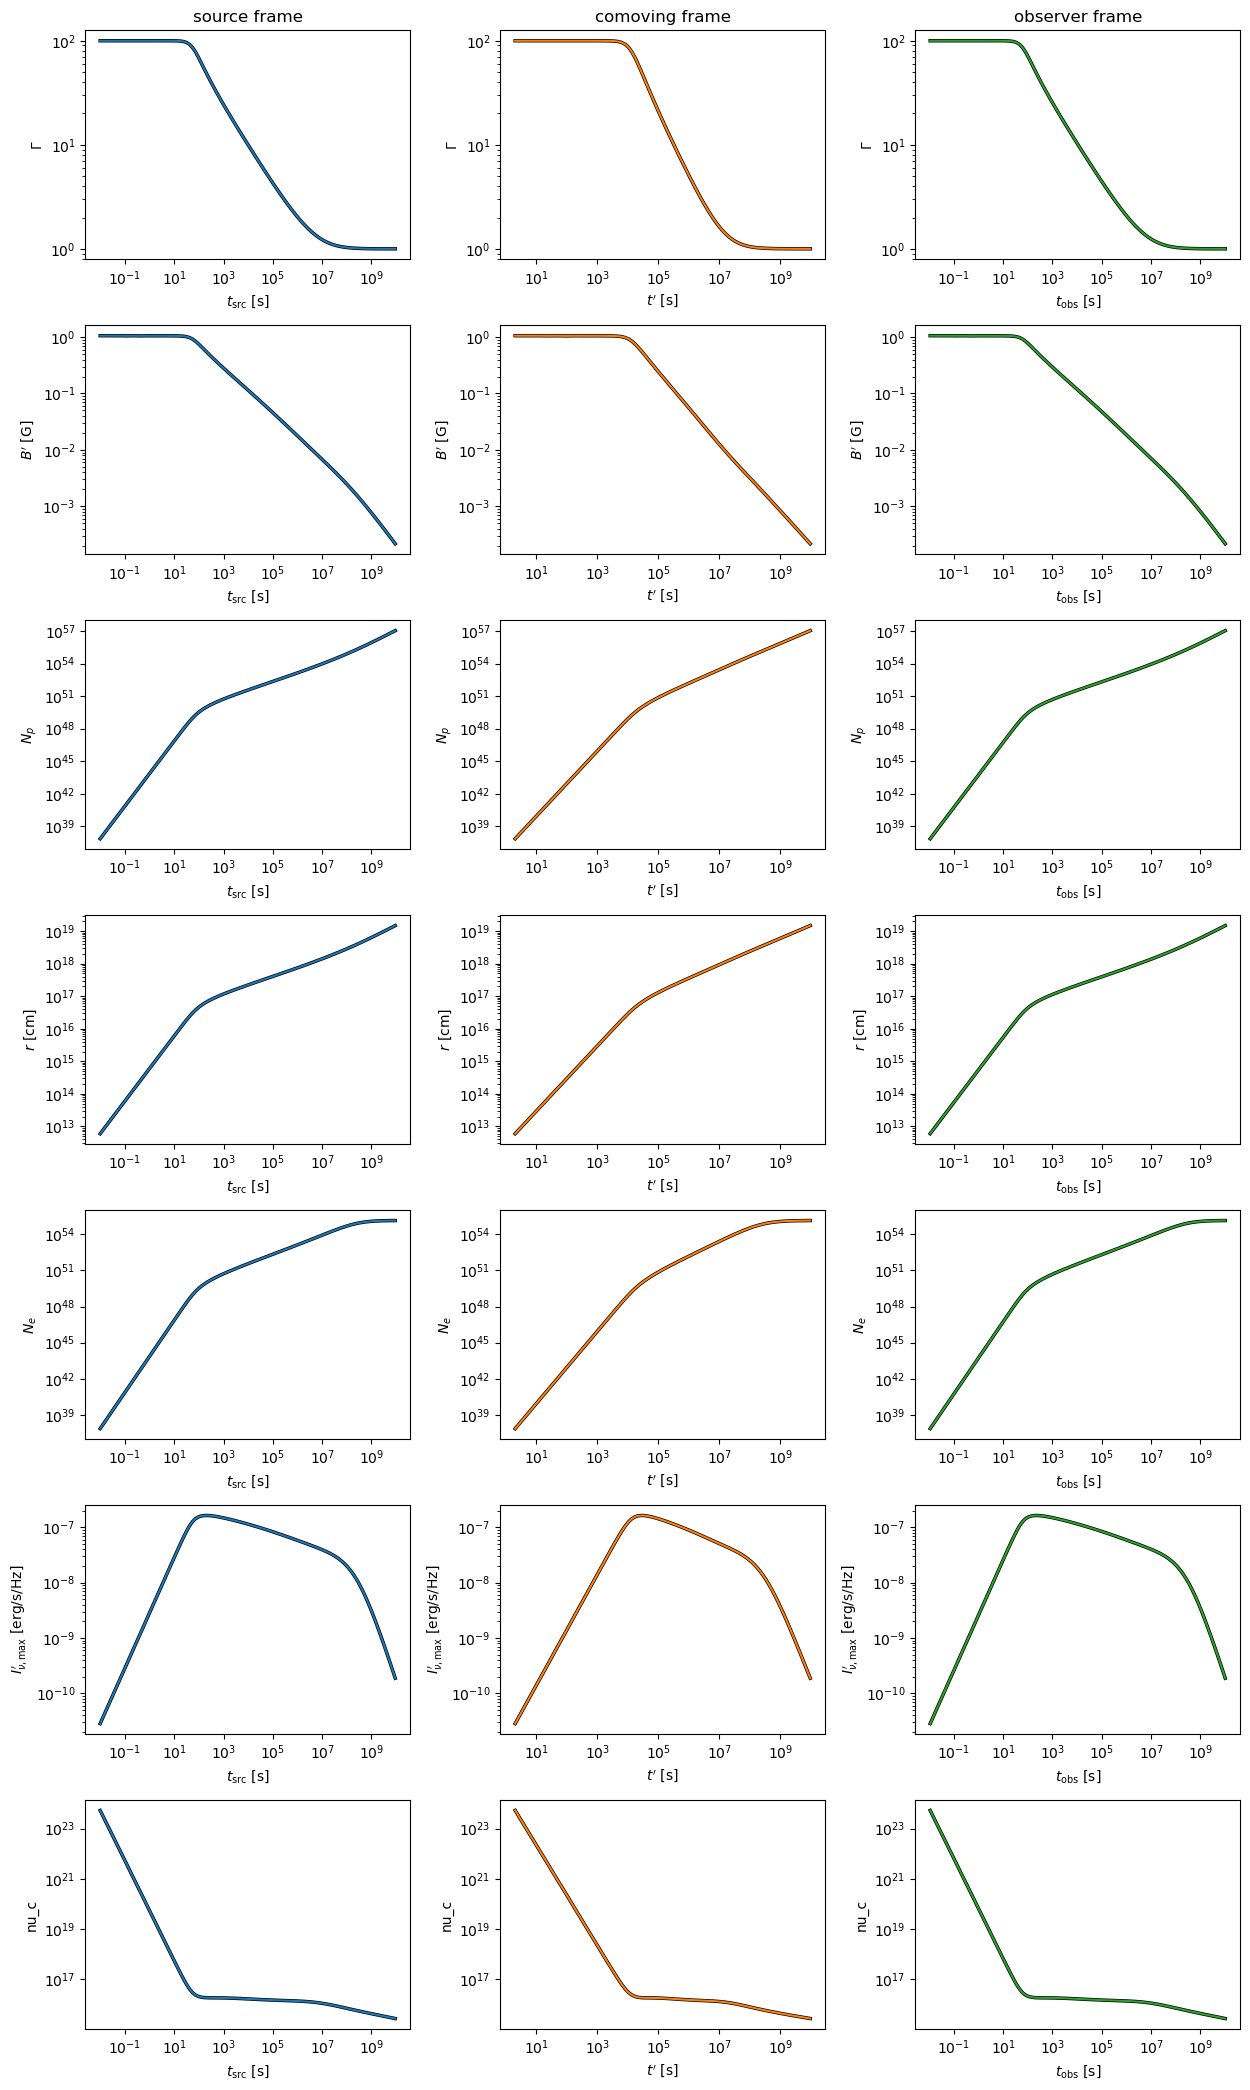

In [106]:
attrs =['Gamma', 'B_comv', 'N_p','r','N_e','I_nu_max', 'nu_c']
ylabels = [r'$\Gamma$', r'$B^\prime$ [G]', r'$N_p$', r'$r$ [cm]', r'$N_e$', r'$I_{\nu, \rm max}^\prime$ [erg/s/Hz]', 'nu_c']

frames = ['t_src', 't_comv', 't_obs']
titles = ['source frame', 'comoving frame', 'observer frame']
colors = ['C0', 'C1', 'C2']
xlabels = [r'$t_{\rm src}$ [s]', r'$t^\prime$ [s]', r'$t_{\rm obs}$ [s]']
plt.figure(figsize= (4.2*len(frames), 3*len(attrs)))

#plot the evolution of various parameters for phi = 0 and theta = 0 (so the first two indexes are 0)
for i, frame in enumerate(frames):
    for j, attr in enumerate(attrs):
        plt.subplot(len(attrs), len(frames) , j * len(frames) + i + 1)
        if j == 0:
            plt.title(titles[i])
        value = getattr(details.fwd, attr)
        # value_rvs = getattr(details.rvs, attr)
        if frame == 't_src':
            t = getattr(details, frame)
            t_rvs = getattr(details, frame)
        else:
            t = getattr(details.fwd, frame)
            t_rvs = getattr(details.rvs, frame)
        plt.loglog(t[0, 0, :], value[0, 0, :], color='k',lw=2.5)
        plt.loglog(t[0, 0, :], value[0, 0, :], color=colors[i])
        # plt.loglog(t_rvs[0, 0, :], value_rvs[0, 0, :], color='k', ls='--', lw=2.5)
        # plt.loglog(t_rvs[0, 0, :], value_rvs[0, 0, :], color=colors[i], ls='--')

        # plt.loglog(t[0, 0, :], t[0, 0, :]**-0.5, color='k',lw=2.5)

        # plt.xlim(1e4, 1e8)
        plt.xlabel(xlabels[i])
        plt.ylabel(ylabels[j])

plt.tight_layout()
# plt.savefig('shock_quantities.png', dpi=300,bbox_inches='tight')

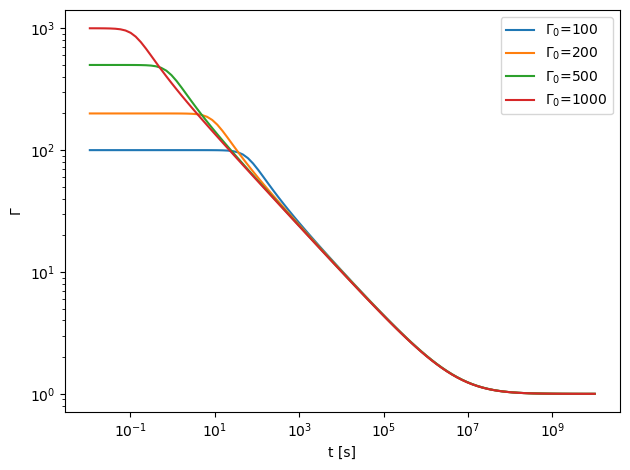

In [ ]:
plt.figure()

attrs =['Gamma']
ylabels = [r'$\Gamma$']

Gamma_0 = [100, 200, 500, 1000]

medium = ISM(n_ism=1)
obs = Observer(lumi_dist=1e26, z=0.1, theta_obs=0)
fwd_rad = Radiation(eps_e=1e-1, eps_B=1e-3, p=2.3)

for i in Gamma_0:
    jet = TophatJet(theta_c=0.1, E_iso=1e52, Gamma0=i, spreading=False)

    model = Model(jet=jet, medium=medium, observer=obs, fwd_rad=fwd_rad, resolutions=(0.1,5,10))

    details = model.details(t_min=1e0, t_max=1e10)

    frames = ['t_src', 't_comv', 't_obs']
    titles = ['source frame', 'comoving frame', 'observer frame']
    colors = ['C0', 'C1', 'C2']
    xlabels = [r'$t_{\rm src}$ [s]', r'$t^\prime$ [s]', r'$t_{\rm obs}$ [s]']
    
    plt.loglog(details.fwd.t_obs[0, 0, :], details.fwd.Gamma[0, 0, :], label=fr'$\Gamma_0$={i}')

plt.xlabel('t [s]')
plt.ylabel(r'$\Gamma$')
plt.legend()
plt.tight_layout()

ValueError: x and y must have same first dimension, but have shapes (200,) and (1,)

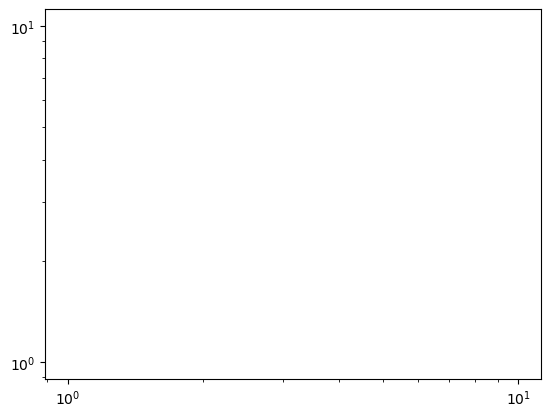

In [121]:
plt.figure()

Gamma_0 = [100, 200, 500, 1000]

medium = ISM(n_ism=1)
obs = Observer(lumi_dist=1e26, z=0.1, theta_obs=0)
fwd_rad = Radiation(eps_e=1e-1, eps_B=1e-3, p=2.3)

t = np.geomspace(1e2, 1e8, 200)
nu = [1e9]
for i in Gamma_0:
    jet = TophatJet(theta_c=0.1, E_iso=1e52, Gamma0=i, spreading=False)

    model = Model(jet=jet, medium=medium, observer=obs, fwd_rad=fwd_rad, resolutions=(0.1,5,10))

    result = model.flux_density_grid(t, nu)
    Fnu = result.total
    
    plt.loglog(t, Fnu, label=fr'$\Gamma_0$={i}')

plt.xlabel('t [s]')
plt.ylabel(r'$\Gamma$')
plt.legend()
plt.tight_layout()